In [1]:
!pip install deepface keras-facenet opencv-contrib-python


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.6 MB/s eta 0:00:00
  Created wheel for keras-facenet: filename=keras_facenet-0.3.2-py3-none-any.whl size=10367 sha256=92d33e8557cdcd02669af4d8bc3a01b1fb9bd9fd68167e08fe4dcf880fcc5a5f
  Stored in directory: /root/.cache/pip/wheels/05/b0/f5/19ac49fedc10b1df3ee56b096edbcfa39d45794fccc6bcdbbf
Successfully built keras-facenet


In [4]:
#BLIP
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import os
import matplotlib.pyplot as plt
import zipfile
with zipfile.ZipFile('/content/face.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')


In [5]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

db_path = "/content/dataset/face"
all_pics = [f for f in os.listdir(db_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

funny-klev-club-nduc-p-smeshnie-kartinki-litsa-akterov-10.jpg -> A Man With A Mustache And A Suit
1455176-873412.jpg -> Robert Mc
funny-klev-club-n9wa-p-smeshnie-kartinki-litsa-akterov-5.jpg -> Actor Charlie Laurman Attends The ' The Walking Dead ' Press Conference At The Paley On March 15


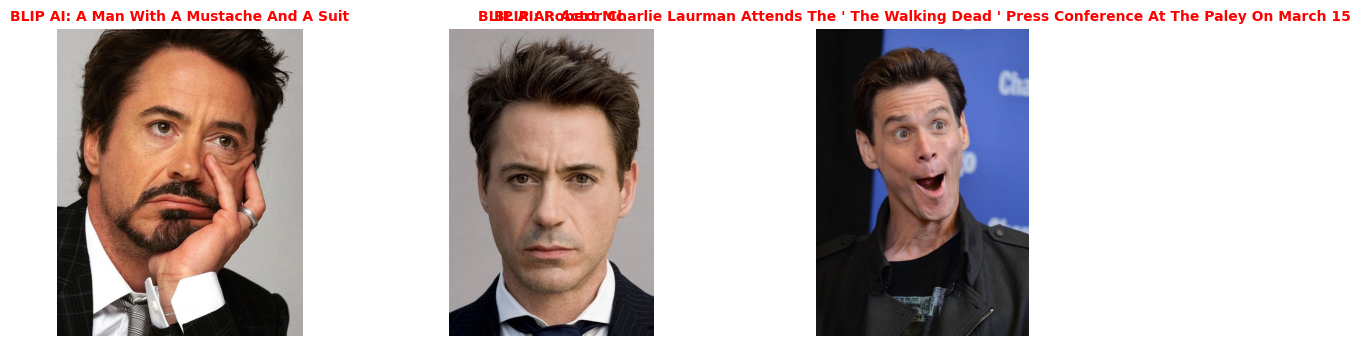

In [6]:
plt.figure(figsize=(15, 10))

for i, file in enumerate(all_pics):
    path = os.path.join(db_path, file)
    raw_img = Image.open(path).convert('RGB')

    inputs = processor(raw_img, return_tensors="pt")
    out = model.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    real_name = caption.replace("a photo of", "").replace("the actor", "").strip().title()

    plt.subplot(3, 4, i + 1)
    plt.imshow(raw_img)
    plt.title(f"BLIP AI: {real_name}", fontsize=10, color='red', fontweight='bold')
    plt.axis('off')
    print(f"{file} -> {real_name}")

plt.tight_layout()
plt.show()

In [8]:
#OpenCV
import numpy as np
import cv2

recognizer = cv2.face.LBPHFaceRecognizer_create()
cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [9]:
faces, labels, names_map = [], [], {}
for i, file in enumerate(all_pics):
    gray = cv2.imread(os.path.join(db_path, file), 0)
    rects = cascade.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in rects:
        faces.append(gray[y:y+h, x:x+w])
        labels.append(i)
        name_clean = " ".join(os.path.splitext(file)[0].split('-')[-2:]).title()
        names_map[i] = name_clean

recognizer.train(faces, np.array(labels))

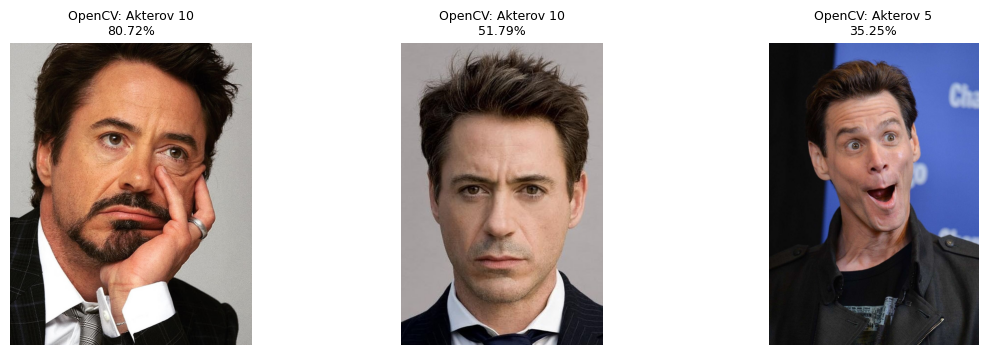

In [10]:
plt.figure(figsize=(15, 10))
for i, file in enumerate(all_pics):
    img = cv2.imread(os.path.join(db_path, file))
    id, conf = recognizer.predict(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
    acc = round(max(0, 100 - conf), 2)

    plt.subplot(3, 4, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"OpenCV: {names_map[id]}\n{acc}%", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()